# Mini Project 3 - Build a Banking Database Insights Agentic AI System

![](https://i.imgur.com/N0zUCi0.png)

## 🎯 Mini Project 3 - Build a Banking Database Insights Agentic AI System with LangGraph

In this project, you will build a **production-ready Database Insights - Text2SQL agent** that autonomously converts natural language business questions into SQL queries, validates them, and executes them against a real banking database.

While traditional database interfaces require SQL expertise, this project introduces **autonomous query generation** using LangGraph's state machine architecture — a powerful paradigm where agents autonomously:
- **Discover** database schemas dynamically
- **Reason** about which tables and columns are relevant
- **Generate** syntactically correct SQL queries
- **Validate** queries before execution
- **Execute** and transform results into business-friendly answers

You will build a **Text2SQL Agent** that can:
- Understand complex business questions in natural language
- Explore unfamiliar databases through schema discovery tools
- Generate multi-table JOIN queries with proper filtering
- Self-correct through query validation
- Present results in clear, non-technical language
- Handle edge cases and provide actionable insights

Instead of relying on hardcoded SQL templates or manual query writing, your agent will **autonomously decide** which tables to inspect, how to join them, and how to filter data — all while ensuring query correctness through validation.

---

### 📋 Learning Objectives

By the end of this project, you will:

- **Build a multi-node LangGraph agent** with custom state management and conditional routing
- Implement a **ReAct-style reasoning loop** for database interaction
- Equip the agent with **SQL database tools** (list tables, inspect schema, validate queries, execute)
- Inject **domain knowledge** through **skill-based context files**
- Handle complex queries end-to-end — from schema discovery to business insights
- Evaluate agent performance using **LLM-as-a-Judge** methodology
- Understand how **stateful agents** maintain context across multiple tool calls

---

### 🏗️ Agent Architecture

The following figure shows the complete agent architecture including all components and the ReAct workflow:

![](https://i.imgur.com/viOzad3.png)

**Text2SQL Agent Simple Workflow:**
```
┌──────────────────────────────────────────────────────────────┐
│                        User Query                            │
│        "Count active accounts by account type."               │
└────────────────────────┬─────────────────────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────┐
        │  LangGraph Text2SQL Agent          │
        │       (GPT-4.1-mini)               │
        │                                    │
        │  ┌──────────────────────────────┐  │
        │  │  1. LOAD: Skill Loader Node  │  │
        │  │     Inject database schema   │  │
        │  │     & business rules         │  │
        │  └──────────────────────────────┘  │
        │              │                     │
        │              ▼                     │
        │  ┌──────────────────────────────┐  │
        │  │  2. THINK: What tables       │  │
        │  │     exist in this database?  │  │
        │  └──────────────────────────────┘  │
        │              │                     │
        │              ▼                     │
        │  ┌──────────────────────────────┐  │
        │  │  3. ACT: sql_db_list_tables  │  │
        │  │     Returns: Customer,       │  │
        │  │     Branch, Account...       │  │
        │  └──────────────────────────────┘  │
        │              │                     │
        │              ▼                     │
        │  ┌──────────────────────────────┐  │
        │  │  4. OBSERVE: Found relevant  │  │
        │  │     tables. Need schemas.    │  │
        │  └──────────────────────────────┘  │
        │              │                     │
        │              ▼                     │
        │  ┌──────────────────────────────┐  │
        │  │  5. ACT: sql_db_schema       │  │
        │  │     (Customer, Branch,       │  │
        │  │      Account, Transactions)  │  │
        │  └──────────────────────────────┘  │
        │              │                     │
        │              ▼                     │
        │  ┌──────────────────────────────┐  │
        │  │  6. OBSERVE: Got columns,    │  │
        │  │     types, relationships.    │  │
        │  │     Generate SQL query.      │  │
        │  └──────────────────────────────┘  │
        │              │                     │
        │              ▼                     │
        │  ┌──────────────────────────────┐  │
        │  │  7. ACT: sql_db_query_checker│  │
        │  │     Validates SQL syntax     │  │
        │  └──────────────────────────────┘  │
        │              │                     │
        │              ▼                     │
        │  ┌──────────────────────────────┐  │
        │  │  8. OBSERVE: Query valid.    │  │
        │  │     Execute it.              │  │
        │  └──────────────────────────────┘  │
        │              │                     │
        │              ▼                     │
        │  ┌──────────────────────────────┐  │
        │  │  9. ACT: sql_db_query        │  │
        │  │     Executes validated SQL   │  │
        │  └──────────────────────────────┘  │
        │              │                     │
        │              ▼                     │
        │  ┌──────────────────────────────┐  │
        │  │  10. THINK: Synthesize       │  │
        │  │      results into business-  │  │
        │  │      friendly answer         │  │
        │  └──────────────────────────────┘  │
        └────────────────────────────────────┘
                         │
                         ▼
        ┌────────────────────────────────────┐
        │    Business-Friendly Answer        │
        │  "There are 22 active accounts.    │
        │   12 are Checking, 10 are Savings."│
        └────────────────────────────────────┘
```

---

### 🛠️ Technical Stack

| Component | Technology | Role |
|-----------|-----------|------|
| **LLM** | GPT-4.1-mini (OpenAI) | Reasoning engine that decides tool usage and generates SQL |
| **Agent Framework** | LangGraph StateGraph | Multi-node state machine with conditional routing |
| **State Management** | TypedDict with add_messages | Maintains conversation history and database context |
| **Database** | SQLite (Banking Insights) | Banking database with 6 tables: Customer, Branch, Account, Merchant, Transactions, Dispute |
| **SQL Tools** | LangChain Community Tools | List tables, inspect schema, validate queries, execute SQL |
| **Skill System** | Markdown-based SKILL.md | Domain knowledge injection (schema, relationships, business rules) |
| **Evaluation** | LLM-as-a-Judge | Semantic correctness assessment against ground truth |

---

### 📚 What You'll Build

In this project, you will implement the following components:

#### 🔧 **Part 1: SQL Database Tools** (4 Tools)
You will initialize and configure four essential tools that enable your agent to interact with the database:
- **sql_db_list_tables** — Discovers available tables
- **sql_db_schema** — Inspects table structure and sample data
- **sql_db_query_checker** — Validates SQL syntax before execution
- **sql_db_query** — Executes validated queries and retrieves results

#### 📝 **Part 2: Agent System Instructions**
You will define a comprehensive system prompt that governs agent behavior, including:
- The 6-step workflow (discover → inspect → generate → validate → execute → present)
- Safety guardrails (read-only operations, no sample data reliance, query validation)
- Output formatting guidelines (business-friendly answers, no SQL shown to users)

#### 📦 **Part 3: Skills Setup**
You will work with a pre-built banking database skill file that contains:
- Complete schema definitions for all 6 tables
- Table relationships and foreign keys
- Valid values for categorical columns
- Common query patterns and business rules

#### 🏗️ **Part 4: LangGraph Agent**
You will build the multi-node agent graph with:
- **State schema** — Shared memory structure with conversation history and skill context
- **3 Node functions** — Skill Loader, Agent (LLM reasoning), and Tools (execution)
- **Conditional routing** — Dynamic graph traversal based on agent decisions
- **Graph compilation** — Wire nodes together into a complete ReAct workflow

#### 🧪 **Part 5: Testing & Evaluation**
You will test your agent with:
- **5 sample queries** covering different banking scenarios (account analysis, spending patterns, customer insights, balances, merchant analysis)
- **LLM-as-a-Judge evaluation** on 3 test cases with reference answers to assess semantic correctness

---

### 📊 Project Workflow
```
Step 1: Environment Setup
   ↓
Step 2: Database Connection (Banking Insights DB)
   ↓
Step 3: Initialize 4 SQL Tools
   ↓
Step 4: Define Agent System Instructions
   ↓
Step 5: Load Banking Database Skill
   ↓
Step 6: Build LangGraph Agent (State + 3 Nodes + Routing)
   ↓
Step 7: Test with 5 Sample Queries
   ↓
Step 8: Evaluate with LLM-as-a-Judge (3 Test Cases)
```

---

### 💡 Key Concepts

#### ReAct Framework (Reasoning + Acting)

**ReAct** combines reasoning and acting in an iterative loop:

1. **Thought** (Reasoning): Agent analyzes the query and decides next action
2. **Action**: Agent calls a tool to gather information (list tables, inspect schema, etc.)
3. **Observation**: Agent receives and processes tool results
4. **Repeat**: Agent continues thinking and acting until query is complete
5. **Answer**: Agent synthesizes results into business-friendly response

Traditional Text2SQL workflow:
```
User Query → LLM → SQL Query → Execute → Results
(High hallucination risk, no validation)
```

ReAct Text2SQL Agent workflow:
```
User Query → DISCOVER tables → INSPECT schema → GENERATE SQL →
VALIDATE syntax → EXECUTE query → SYNTHESIZE answer
(Self-correcting, loops when needed, grounded in actual schema)
```

#### Skill-Based Context

**Skills** are structured knowledge files that provide:
- Complete database schema definitions
- Table relationships and foreign keys
- Valid values for categorical columns (e.g., account types, transaction types)
- Business rules and constraints
- Common query patterns

This gives the agent **domain expertise** without hardcoding database details into the agent code itself.

---

### ✅ Learning Outcomes

By completing this project, you will understand:

✅ **LangGraph Architecture** — Building multi-node state machines with conditional edges  
✅ **ReAct Framework** — How agents autonomously discover, reason, and act in loops  
✅ **SQL Tool Orchestration** — Schema discovery, validation, and safe query execution  
✅ **Skill-Based Context** — Injecting domain knowledge without hardcoding  
✅ **State Management** — How agents maintain context across multiple tool calls  
✅ **Conditional Routing** — Dynamic graph traversal based on agent decisions  
✅ **LLM-as-a-Judge Evaluation** — Assessing semantic correctness vs exact string matching  

**Key Difference from Basic LLM Calls:** Instead of one-shot SQL generation (which often hallucinates table names or creates invalid syntax), your agent **discovers schema dynamically**, **validates before executing**, and **self-corrects through multiple reasoning steps**.

---

**Let's build your autonomous Banking Database Insights - Text2SQL agent!** 🚀

---

## 📦 Environment Setup & Dependencies

### Installation

We install all required packages for building our Text2SQL agentic system.

| Package | Purpose |
|---------|---------|
| `langchain` | Core LangChain framework for agent creation and tool orchestration |
| `langchain-openai` | OpenAI LLM (GPT-4.1-mini) for SQL generation and validation |
| `langchain-community` | SQL database tools and utilities (QuerySQLDatabaseTool, InfoSQLDatabaseTool, etc.) |
| `langgraph` | Graph-based agent runtime for state management and conditional routing |

In [1]:
!pip install -q langchain==1.2.10
!pip install -q langchain-openai==1.1.10
!pip install -q langchain-community==0.4.1
!pip install -q langgraph==1.0.9

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.9/160.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 kB 4.6 MB/s eta 0:00:00


---

## 🗄️ Database Setup

### Installing SQLite

We use **SQLite** as our database engine — a lightweight, serverless, file-based database perfect for development and testing.

**Why SQLite for this project:**
- No separate server process required
- Zero configuration needed
- Cross-platform compatibility
- Full SQL support (JOINs, aggregations, subqueries)


In [2]:
!apt-get install sqlite3 -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  sqlite3-doc
The following NEW packages will be installed:
  sqlite3
0 upgraded, 1 newly installed, 0 to remove and 5 not upgraded.
Need to get 769 kB of archives.
After this operation, 1,874 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 sqlite3 amd64 3.37.2-2ubuntu0.5 [769 kB]
Fetched 769 kB in 1s (734 kB/s)
Selecting previously unselected package sqlite3.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../sqlite3_3.37.2-2ubuntu0.5_amd64.deb ...
Unpacking sqlite3 (3.37.2-2ubuntu0.5) ...
Setting up sqlite3 (3.37.2-2ubuntu0.5) ...
Processing triggers for man-db (2.10.2-1) ...


---

## 🔐 API Authentication

### Setting Up API Keys

We securely configure the OpenAI API key using `getpass`, which prompts for input without displaying the key in notebook output or storing it in the cell.

> **Security Best Practice:** Never hardcode API keys directly in your notebook. Using `getpass` ensures keys stay out of version control and shared outputs.

You will need:
- **OpenAI API Key** — Powers LLM (GPT-4.1-mini) for the agent. Get yours at [platform.openai.com/api-keys](https://platform.openai.com/api-keys)

In [3]:
# get api key
import os
from google.colab import userdata
os.environ['OPENAI_API_KEY'] = userdata.get("OPENAI_API_KEY")

In [ ]:
# import os
# from getpass import getpass

# # OpenAI API Key (for chat)
# os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key : ")

---

## 📥 Downloading the  Banking Insights Database

We download a pre-populated ** Banking Insights Database** that contains realistic business operations data.

This database demonstrates Text2SQL capabilities on:
- Multi-table relational structure (5 tables with foreign keys)
- Real-world business scenarios (departments, workflows, audit logs)
- Complex queries requiring JOINs and aggregations

> **Troubleshooting:** If `gdown` fails, manually download from [this link](https://drive.google.com/file/d/1ayUkdVRPBE4lZVIyHSjVpXfwljhbdwNi/view?usp=sharing) and upload to your notebook environment.

In [4]:
# in case of issues download from https://drive.google.com/file/d/1ayUkdVRPBE4lZVIyHSjVpXfwljhbdwNi/view?usp=sharing and upload
! gdown 1ayUkdVRPBE4lZVIyHSjVpXfwljhbdwNi

Downloading...
From: https://drive.google.com/uc?id=1ayUkdVRPBE4lZVIyHSjVpXfwljhbdwNi
To: /content/banking_insights.db
100% 160k/160k [00:00<00:00, 50.3MB/s]


---

## 🔌 Connecting to the Database

### Verifying SQLite Installation and Database Access

Before building our agent, we verify that:
1. SQLite is properly installed
2. The database file exists and is accessible
3. Tables were created successfully

In [5]:
!sqlite3 --version

3.37.2 2022-01-06 13:25:41 872ba256cbf61d9290b571c0e6d82a20c224ca3ad82971edc46b29818d5dalt1


In [6]:
!sqlite3 banking_insights.db "SELECT name FROM sqlite_master WHERE type='table';"

Customer
Branch
Account
Merchant
Transactions
Dispute


In [7]:
%%bash
sqlite3 banking_insights.db <<EOF
.headers on
.mode column
SELECT * FROM transactions LIMIT 10;
EOF

TxnID       AccountID  TxnDate              AmountUSD  TxnType  Channel  MerchantID  Category  Description                      
----------  ---------  -------------------  ---------  -------  -------  ----------  --------  ---------------------------------
TKRPSA3UOQ  1005       2024-08-27 08:25:24  3878.54    Credit   Branch   2           Salary    Payment processed for Amanda     
TLICMDYFS0  1022       2024-01-13 22:59:29  4588.52    Credit   Online   2           Salary    Payment processed for Christopher
T768GQE1MA  1016       2024-06-28 10:34:19  2708.43    Credit   Online   2           Salary    Payment processed for Rahul      
TY1SP0L0A8  1021       2024-01-23 14:49:10  7812.71    Credit   Branch   2           Salary    Payment processed for Christopher
TYYCGN91Y0  1016       2024-05-28 11:45:08  5882.78    Credit   Online   2           Salary    Payment processed for Rahul      
T6AJO9160A  1002       2025-02-15 15:51:52  9769.54    Credit   Online   2           Salary    Pa

---

### 🔗 Creating LangChain Database Connection

We initialize a **LangChain SQLDatabase** object that wraps our SQLite connection.

This object provides:
- Standardized python interface for SQL tools
- Schema introspection capabilities
- Safe query execution
- Dialect-aware query generation

In [8]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///banking_insights.db")
db

In [9]:
print(db.dialect)
print(db.get_usable_table_names())

sqlite
['Account', 'Branch', 'Customer', 'Dispute', 'Merchant', 'Transactions']


# Added overview for Banking database and remove operations database overview

---

## 📊 Overview of the Banking Insights Database

In this project, you will work with a **Banking Insights Database** that simulates real-world consumer banking data. This database demonstrates Text2SQL capabilities on complex financial scenarios involving customer accounts, transaction analysis, and dispute management.

### Database Schema

The database contains **6 interconnected tables** representing different aspects of banking operations:

| Table | Description |
|-------|-------------|
| **Customer** | Individual account holders with profile information (name, city, state) |
| **Branch** | Physical branch locations that service customer accounts |
| **Account** | Deposit accounts (Checking, Savings, Business Checking) with type, open date, and status tracking |
| **Merchant** | Transaction counterparties including retailers (Walmart, Target), service providers (AT&T, Netflix), travel (Delta, Marriott), and dining (Starbucks) |
| **Transactions** | Complete transaction history with amount, type (Credit/Debit), channel (ATM/POS/Online/Branch), category, and merchant details |
| **Dispute** | Customer dispute cases linked to specific transactions with reason codes, status, and resolutions |

### 🔄 Entity Relationships

The tables are connected through foreign keys, enabling complex JOIN operations:

- A **Customer** owns one or more **Accounts**
- A **Branch** services multiple **Accounts**
- An **Account** generates many **Transactions**
- A **Merchant** appears in multiple **Transactions**
- A **Transaction** can trigger zero or more **Disputes**

### 💡 Use Cases Enabled

This schema allows the agent to answer sophisticated banking questions such as:

- **Customer analysis**: "Which branch has the highest number of customers?"
- **Spend analysis**: "What are the top spending categories by transaction value?"
- **Account insights**: "Show me the top 5 accounts by current balance with customer names"
- **Transaction patterns**: "Which customers have the highest dining spend in 2025?"
- **Dispute tracking**: "What disputes are unresolved and linked to which merchants?"

The agent autonomously discovers schema, generates SQL, validates queries, and transforms database results into actionable banking insights.

![](https://i.imgur.com/Vad8yQS.png)

Test some sample queries to get a feel for the database

In [10]:
db.run("SELECT * FROM Transactions LIMIT 10;", include_columns=True)

"[{'TxnID': 'TKRPSA3UOQ', 'AccountID': 1005, 'TxnDate': '2024-08-27 08:25:24', 'AmountUSD': 3878.54, 'TxnType': 'Credit', 'Channel': 'Branch', 'MerchantID': 2, 'Category': 'Salary', 'Description': 'Payment processed for Amanda'}, {'TxnID': 'TLICMDYFS0', 'AccountID': 1022, 'TxnDate': '2024-01-13 22:59:29', 'AmountUSD': 4588.52, 'TxnType': 'Credit', 'Channel': 'Online', 'MerchantID': 2, 'Category': 'Salary', 'Description': 'Payment processed for Christopher'}, {'TxnID': 'T768GQE1MA', 'AccountID': 1016, 'TxnDate': '2024-06-28 10:34:19', 'AmountUSD': 2708.43, 'TxnType': 'Credit', 'Channel': 'Online', 'MerchantID': 2, 'Category': 'Salary', 'Description': 'Payment processed for Rahul'}, {'TxnID': 'TY1SP0L0A8', 'AccountID': 1021, 'TxnDate': '2024-01-23 14:49:10', 'AmountUSD': 7812.71, 'TxnType': 'Credit', 'Channel': 'Branch', 'MerchantID': 2, 'Category': 'Salary', 'Description': 'Payment processed for Christopher'}, {'TxnID': 'TYYCGN91Y0', 'AccountID': 1016, 'TxnDate': '2024-05-28 11:45:08', 

In [11]:
db.run("SELECT * FROM Customer LIMIT 10;", include_columns=True)

"[{'CustomerID': 1, 'Name': 'Sarah Johnson', 'City': 'New York', 'State': 'NY'}, {'CustomerID': 2, 'Name': 'Michael Chen', 'City': 'San Francisco', 'State': 'CA'}, {'CustomerID': 3, 'Name': 'Emily Rodriguez', 'City': 'Los Angeles', 'State': 'CA'}, {'CustomerID': 4, 'Name': 'David Kim', 'City': 'Chicago', 'State': 'IL'}, {'CustomerID': 5, 'Name': 'Jessica Williams', 'City': 'Houston', 'State': 'TX'}, {'CustomerID': 6, 'Name': 'James Martinez', 'City': 'Miami', 'State': 'FL'}, {'CustomerID': 7, 'Name': 'Amanda Taylor', 'City': 'Seattle', 'State': 'WA'}, {'CustomerID': 8, 'Name': 'Robert Anderson', 'City': 'Boston', 'State': 'MA'}, {'CustomerID': 9, 'Name': 'Lisa Thompson', 'City': 'Austin', 'State': 'TX'}, {'CustomerID': 10, 'Name': 'Christopher Lee', 'City': 'Denver', 'State': 'CO'}]"

In [12]:
db.run("SELECT * FROM Account LIMIT 10;", include_columns=True)

"[{'AccountID': 1001, 'CustomerID': 1, 'BranchID': 1, 'AccountType': 'Checking', 'OpenDate': '2023-01-15', 'Status': 'Active'}, {'AccountID': 1002, 'CustomerID': 3, 'BranchID': 2, 'AccountType': 'Checking', 'OpenDate': '2022-06-22', 'Status': 'Active'}, {'AccountID': 1003, 'CustomerID': 4, 'BranchID': 1, 'AccountType': 'Checking', 'OpenDate': '2023-03-10', 'Status': 'Active'}, {'AccountID': 1004, 'CustomerID': 6, 'BranchID': 1, 'AccountType': 'Checking', 'OpenDate': '2021-11-05', 'Status': 'Active'}, {'AccountID': 1005, 'CustomerID': 7, 'BranchID': 2, 'AccountType': 'Checking', 'OpenDate': '2023-08-14', 'Status': 'Active'}, {'AccountID': 1006, 'CustomerID': 9, 'BranchID': 1, 'AccountType': 'Checking', 'OpenDate': '2022-12-01', 'Status': 'Active'}, {'AccountID': 1007, 'CustomerID': 11, 'BranchID': 1, 'AccountType': 'Checking', 'OpenDate': '2023-05-20', 'Status': 'Active'}, {'AccountID': 1008, 'CustomerID': 13, 'BranchID': 3, 'AccountType': 'Checking', 'OpenDate': '2022-09-18', 'Status':

In [13]:
db.run("SELECT * FROM Merchant LIMIT 10;", include_columns=True)

"[{'MerchantID': 1, 'Name': 'Walmart'}, {'MerchantID': 2, 'Name': 'Amazon'}, {'MerchantID': 3, 'Name': 'Starbucks'}, {'MerchantID': 4, 'Name': 'Target'}, {'MerchantID': 5, 'Name': 'Whole Foods'}, {'MerchantID': 6, 'Name': 'Apple'}, {'MerchantID': 7, 'Name': 'Samsung'}, {'MerchantID': 8, 'Name': 'Nike'}, {'MerchantID': 9, 'Name': 'Delta Airlines'}, {'MerchantID': 10, 'Name': 'Marriott'}]"

In [14]:
db.run("SELECT * FROM Dispute LIMIT 10;", include_columns=True)

"[{'DisputeID': 'D001', 'TxnID': 'TWZNN7R8D5', 'RaisedDate': '2023-10-10', 'ReasonCode': 'Fraudulent', 'Status': 'Open', 'Resolution': None}, {'DisputeID': 'D002', 'TxnID': 'TFIPGU6TRZ', 'RaisedDate': '2025-02-01', 'ReasonCode': 'Fraudulent', 'Status': 'Open', 'Resolution': None}, {'DisputeID': 'D003', 'TxnID': 'TXO5CZ2NRX', 'RaisedDate': '2023-11-03', 'ReasonCode': 'Fraudulent', 'Status': 'Open', 'Resolution': None}, {'DisputeID': 'D004', 'TxnID': 'T912QRHKCT', 'RaisedDate': '2023-12-09', 'ReasonCode': 'Unauthorized', 'Status': 'Open', 'Resolution': None}, {'DisputeID': 'D005', 'TxnID': 'TW7Z3AU4LY', 'RaisedDate': '2023-10-05', 'ReasonCode': 'Unauthorized', 'Status': 'Under Investigation', 'Resolution': None}, {'DisputeID': 'D006', 'TxnID': 'TOC6VQPNAT', 'RaisedDate': '2024-04-23', 'ReasonCode': 'Duplicate', 'Status': 'Under Investigation', 'Resolution': None}, {'DisputeID': 'D007', 'TxnID': 'TKVDL57K5L', 'RaisedDate': '2025-01-22', 'ReasonCode': 'Duplicate', 'Status': 'Resolved', 'Re

---

## 🔧 SQL Database Tools Overview

In this section, you will set up the **core tools** that enable your Text2SQL agent to interact with the database autonomously.

### Why Tools Matter in Agentic Workflows

Unlike traditional systems where SQL queries are hardcoded, your agent will **dynamically discover and validate** queries at runtime. This requires a toolkit that allows the agent to:

1. **Explore** the database structure without prior knowledge
2. **Inspect** table schemas and sample data
3. **Validate** generated SQL before execution
4. **Execute** queries safely and retrieve results

### The Four Essential SQL Tools

Your agent will use four specialized tools, each serving a distinct purpose in the Text2SQL workflow:

| Tool | Purpose | When the Agent Uses It |
|------|---------|------------------------|
| **DB_LIST_TABLES → sql_db_list_tables** | Lists all available tables in the database | First step: Discover what tables exist before querying |
| **DB_SCHEMA → sql_db_schema** | Retrieves detailed schema (columns, types, sample rows) for specific tables | Second step: Understand structure of relevant tables |
| **DB_QUERY_CHECKER → sql_db_query_checker** | Validates SQL syntax and logic before execution | Third step: Ensure query is syntactically correct and safe |
| **DB_QUERY → sql_db_query** | Executes the validated SQL query and returns results | Final step: Retrieve actual data from the database |

### Tool Workflow in Action

Here's how the agent uses these tools in sequence for a typical query:
```
User: "Which branch has the highest number of customers?"

Agent Reasoning:

- Use DB Schema Skill to get further database context
- Run the following steps
- Steps 1 - 5 can run multiple times in case it is not able to get all info in one go
- This is the agentic loop

1. → Call sql_db_list_tables → Discovers: Customer, Branch, Account, Merchant, Transactions, Dispute
2. → Call sql_db_schema("Customer, Branch, Account") → Inspects relevant schemas
3. → Generate SQL with JOINs and filters
4. → Call sql_db_query_checker(generated_sql) → Validates syntax
5. → Call sql_db_query(validated_sql) → Executes and gets results
6. → Synthesize business-friendly answer
```

This **tool-driven approach** ensures the agent never guesses table names, hallucinates columns, or executes invalid SQL.

![](https://i.imgur.com/iVSrFE3.png)

In the following sections, you will initialize each tool and test them individually before integrating them into the agent.

### Listing Available Tables in the Database

In this step, you will initialize the **table discovery tool** that allows the agent to view all tables present in the connected SQL database.

This is the **first and most critical step** in a Text-to-SQL workflow because the agent must:

- Understand **what tables exist**
- Avoid **guessing schema names**
- Ground its reasoning in the **actual database structure**

You will use LangChain's `ListSQLDatabaseTool`, which:

- Accepts an **empty input**
- Returns a **comma-separated list of table names**
- Helps the agent decide **which tables are relevant** for a given query

The following code initializes this tool and prepares it for use inside the agent's tool-calling workflow.

---



In [15]:
from langchain_community.tools.sql_database.tool import ListSQLDatabaseTool

db_list_tool = ListSQLDatabaseTool(db=db)
print("Tool Name:", db_list_tool.name)
print("Tool Description:", db_list_tool.description)


Tool Name: sql_db_list_tables
Tool Description: Input is an empty string, output is a comma-separated list of tables in the database.


In [16]:
# Test the tool
db_list_tool.run("")

'Account, Branch, Customer, Dispute, Merchant, Transactions'

---

## Inspecting Table Schema and Sample Data

In this step, you will initialize the **schema inspection tool**, which allows the agent to understand the **structure and contents** of selected database tables.

After discovering available tables, the agent must examine:

- **Column names**
- **Data types**
- **Sample rows**

This ensures the agent can:

- Write **syntactically correct SQL queries**
- Reference **valid columns and tables**
- Avoid **hallucinated fields or incorrect joins**

You will use LangChain's `InfoSQLDatabaseTool`, which:

- Takes a **comma-separated list of table names** as input  
- Returns the **schema definition and example rows** for those tables  
- Provides the structural context needed for **accurate Text-to-SQL generation**

The following code initializes this tool so it can be used within the agent's reasoning and query construction workflow.

---

**YOUR TURN: Implement this tool below** ↓

In [ ]:
# 

from langchain_community.tools.sql_database.tool import InfoSQLDatabaseTool

db_info_tool = InfoSQLDatabaseTool(db=db)
print("Tool Name:", db_info_tool.name)
print("Tool Description:", db_info_tool.description)


Tool Name: sql_db_schema
Tool Description: Get the schema and sample rows for the specified SQL tables.


In [18]:
# Test the tool
print(db_info_tool.run("Account"))


CREATE TABLE "Account" (
	"AccountID" INTEGER, 
	"CustomerID" INTEGER, 
	"BranchID" INTEGER, 
	"AccountType" TEXT, 
	"OpenDate" DATE, 
	"Status" TEXT, 
	PRIMARY KEY ("AccountID")
)

/*
3 rows from Account table:
AccountID	CustomerID	BranchID	AccountType	OpenDate	Status
1001	1	1	Checking	2023-01-15	Active
1002	3	2	Checking	2022-06-22	Active
1003	4	1	Checking	2023-03-10	Active
*/


## Viewing the Built-in SQL Query Checker Prompt

In this step, we examine the **predefined SQL query checker prompt** provided by LangChain.  
This prompt is designed to help an LLM **review, validate, and correct** SQL queries before they are executed on the database.

Using a query checker is important because LLM-generated SQL may contain:

- **Syntax errors**
- **Incorrect table or column names**
- **Logical mistakes in filtering or joins**

By validating the query before execution, we can:

- Improve **accuracy and reliability**
- Prevent **runtime database errors**
- Enforce **safer, production-ready query execution**

Here, we import and print the `QUERY_CHECKER` prompt to understand the exact **instructions used for SQL validation** inside the agent workflow.  
This also allows us to **customize or extend** the validation logic if needed.


In [19]:
from langchain_community.tools.sql_database.prompt import QUERY_CHECKER

print(QUERY_CHECKER)


{query}
Double check the {dialect} query above for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes, just reproduce the original query.

Output the final SQL query only.

SQL Query: 


In [ ]:


QUERY_CHECKER_TEMPLATE = """You are a SQL expert. Review the following {dialect} SQL query for correctness.

Check for these common issues:
- Syntax errors (wrong keywords, missing clauses)
- Invalid table or column names (not in the schema)
- Wrong use of JOINs or missing JOIN conditions
- Incorrect aggregation or GROUP BY usage
- Missing quotes around string literals
- Incorrect LIMIT or ORDER BY usage
- DML statements (INSERT, UPDATE, DELETE, DROP) — flag these as unsafe

Original query:
{query}

If the query is correct, return it unchanged.
If it has errors, return only the corrected SQL query with no extra explanation.

Corrected SQL Query:
"""
print(QUERY_CHECKER_TEMPLATE)


You are a SQL expert. Review the following {dialect} SQL query for correctness.

Check for these common issues:
- Syntax errors (wrong keywords, missing clauses)
- Invalid table or column names (not in the schema)
- Wrong use of JOINs or missing JOIN conditions
- Incorrect aggregation or GROUP BY usage
- Missing quotes around string literals
- Incorrect LIMIT or ORDER BY usage
- DML statements (INSERT, UPDATE, DELETE, DROP) — flag these as unsafe

Original query:
{query}

If the query is correct, return it unchanged.
If it has errors, return only the corrected SQL query with no extra explanation.

Corrected SQL Query:



---

## Initializing the SQL Query Checker with OpenAI

In this step, you will configure an **LLM-powered SQL query validation tool** using OpenAI.

The purpose of this tool is to **review and correct SQL queries before execution**, which helps:

- Prevent **syntax errors**
- Detect **invalid tables or columns**
- Improve **overall query reliability**
- Enforce **safe, production-ready database interaction**

You will use:

- **`ChatOpenAI (gpt-4.1-mini)`** as the judging and validation model  
- **`QuerySQLCheckerTool`** from LangChain to wrap the validation workflow  
- The built-in **`QUERY_CHECKER` prompt template** to standardize how SQL is reviewed  

This ensures that every generated SQL query is:

**Validated → Corrected if needed → Safe to execute**

Such validation is a critical guardrail when building **real-world Text-to-SQL agent systems**.

---

In [ ]:
# 

from langchain_community.tools.sql_database.tool import QuerySQLCheckerTool
from langchain_openai import ChatOpenAI

checker_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

query_checker_tool = QuerySQLCheckerTool(db=db, llm=checker_llm)
print("Tool Name:", query_checker_tool.name)
print("Tool Description:", query_checker_tool.description)


Tool Name: sql_db_query_checker
Tool Description: 
    Use this tool to double check if your query is correct before executing it.
    Always use this tool before executing a query with sql_db_query!
    


In [22]:
# Test the tool
# Define the SQL query
query = """SELECT * and FROM Transactions LIMIT 10;""" #  Incorrect SQL command

# Validate the query using QuerySQLCheckerTool
validated_query = query_checker_tool.run(query)
print(validated_query) # This will give the correct query

SELECT * FROM Transactions LIMIT 10;


---

## Executing SQL Queries on the Database

In this step, you will initialize the **SQL query execution tool**, which enables the agent to run validated SQL queries directly on the connected database and retrieve real results.

This represents the **final action stage** of the Text-to-SQL workflow.  
After the agent:

1. Discovers available tables  
2. Inspects the relevant schema  
3. Validates the generated SQL query  

…it must **execute the query** to obtain **grounded, factual data**.

You will use LangChain's `QuerySQLDatabaseTool`, which:

- Accepts a **fully formed SQL query** as input  
- Executes the query on the database  
- Returns the **actual query results** or an **error message** if the SQL is invalid  

This step is essential because it ensures the agent's final answer is based on **real database outputs**, not hallucinated information.

The following code initializes this execution tool so it can be used within the agent's tool-calling workflow.

---


In [ ]:


from langchain_community.tools.sql_database.tool import QuerySQLDatabaseTool

db_query_tool = QuerySQLDatabaseTool(db=db)
print("Tool Name:", db_query_tool.name)
print("Tool Description:", db_query_tool.description)


Tool Name: sql_db_query
Tool Description: 
    Execute a SQL query against the database and get back the result..
    If the query is not correct, an error message will be returned.
    If an error is returned, rewrite the query, check the query, and try again.
    


In [24]:
# Test the tool
result = db_query_tool.run("""
SELECT * FROM Customer LIMIT 2
""")
print(result)

[(1, 'Sarah Johnson', 'New York', 'NY'), (2, 'Michael Chen', 'San Francisco', 'CA')]


In [25]:
# Test the tool
result = db_query_tool.run(validated_query)
print(result)

[('TKRPSA3UOQ', 1005, '2024-08-27 08:25:24', 3878.54, 'Credit', 'Branch', 2, 'Salary', 'Payment processed for Amanda'), ('TLICMDYFS0', 1022, '2024-01-13 22:59:29', 4588.52, 'Credit', 'Online', 2, 'Salary', 'Payment processed for Christopher'), ('T768GQE1MA', 1016, '2024-06-28 10:34:19', 2708.43, 'Credit', 'Online', 2, 'Salary', 'Payment processed for Rahul'), ('TY1SP0L0A8', 1021, '2024-01-23 14:49:10', 7812.71, 'Credit', 'Branch', 2, 'Salary', 'Payment processed for Christopher'), ('TYYCGN91Y0', 1016, '2024-05-28 11:45:08', 5882.78, 'Credit', 'Online', 2, 'Salary', 'Payment processed for Rahul'), ('T6AJO9160A', 1002, '2025-02-15 15:51:52', 9769.54, 'Credit', 'Online', 2, 'Salary', 'Payment processed for Emily'), ('TR0S135W0V', 1011, '2024-05-15 01:04:04', 10859.45, 'Credit', 'Online', 2, 'Salary', 'Payment processed for Michael'), ('TWAAP780PP', 1008, '2024-04-17 21:13:02', 5795.78, 'Credit', 'Online', 2, 'Salary', 'Payment processed for Yuki'), ('THSH0DVFJ7', 1022, '2024-12-20 08:24:5

---

### 📋 Collecting All SQL Tools

Now that you've initialized and tested each tool individually, you will collect them into a single list that will be passed to your LangGraph agent.

This list represents the **complete toolkit** the agent can autonomously choose from when processing user queries.

Let's verify all tools are properly configured by inspecting their names, descriptions, and expected input arguments:

---


In [ ]:


db_tools = [db_list_tool, db_info_tool, query_checker_tool, db_query_tool]


In [27]:
# Check tool details
for tool in db_tools:
    print('Tool Name:', tool.name)
    print('Tool Description:', tool.description)
    print('Tool Args:', tool.args)
    print()

Tool Name: sql_db_list_tables
Tool Description: Input is an empty string, output is a comma-separated list of tables in the database.
Tool Args: {'tool_input': {'default': '', 'description': 'An empty string', 'title': 'Tool Input', 'type': 'string'}}

Tool Name: sql_db_schema
Tool Description: Get the schema and sample rows for the specified SQL tables.
Tool Args: {'table_names': {'description': "A comma-separated list of the table names for which to return the schema. Example input: 'table1, table2, table3'", 'title': 'Table Names', 'type': 'string'}}

Tool Name: sql_db_query_checker
Tool Description: 
    Use this tool to double check if your query is correct before executing it.
    Always use this tool before executing a query with sql_db_query!
    
Tool Args: {'query': {'description': 'A detailed and SQL query to be checked.', 'title': 'Query', 'type': 'string'}}

Tool Name: sql_db_query
Tool Description: 
    Execute a SQL query against the database and get back the result..
  

---

## 📦 Skills Package Setup

### What are Skills?

**Skills** are structured knowledge files (and optionally code scripts) that provide domain-specific context to the agent.

For Text2SQL, a skill can contain:
- Complete database schema with relationships
- Business logic and constraints
- Valid values for enum-like columns
- Example queries and patterns

**Why use skills instead of just schema inspection?**

While tools can discover tables and columns dynamically, skills provide:
- **Enterprise governance** — Centralized, version-controlled knowledge base that ensures consistent behavior across teams and environments
- **Semantic understanding** — What does "Quarter" mean? Format: "Q1-2024"
- **Business rules** — Which departments are valid? What workflows exist?
- **Relationships** — How do tables connect? What are common query patterns?
- **Performance hints** — Which columns to index on, optimal JOIN strategies

This dramatically improves query quality and reduces errors.

---

### 📂 Accessing the Database Skill Package

Now that we understand why skills are valuable, let's access our pre-built **banking_insights.db** skill file.

#### How Skills Are Structured

A skill package follows a standardized directory structure:
```
db_skills/
└── banking-insights-db/          # Skill name (database-specific separate folders)
    └── SKILL.md                     # Main skill file containing all context
```

Each `SKILL.md` file is a **structured markdown document** that contains:

- **Database schema definitions** — Complete CREATE TABLE statements with column types and constraints
- **Table relationships** — Foreign key mappings and JOIN patterns
- **Sample data and valid values** — Enum-like columns (e.g., valid department names, quarter formats)
- **Business logic** — Domain-specific rules and constraints
- **Common query patterns** — Example SQL queries for frequent use cases
- **Metadata** — Database dialect, version, last updated timestamp

#### Why Markdown for Skills?

Using markdown instead of JSON or YAML provides:
- **Human-readable** — Easy to review, edit, and maintain
- **Version-controllable** — Track changes via Git with clear diffs
- **LLM-friendly** — Large language models excel at understanding structured text
- **Flexible** — Can include explanations, examples, and context alongside schema

#### Extracting the Skill Package

The skills are distributed as a `.zip` file for easy portability. Let's extract and verify the structure:

**Note: We have created a skill file for you so you can focus on agent building but feel free to create your own or modify the below file if you wish to!**

Get the skill file [from here](https://drive.google.com/file/d/1AEGATQkRJ0-cGF8qwFW0emulsjcuqbaq/view?usp=sharing) or just run the code below

In [28]:
# Download from https://drive.google.com/file/d/1AEGATQkRJ0-cGF8qwFW0emulsjcuqbaq/view?usp=sharing and upload in case the following code doesn't work
!gdown 1AEGATQkRJ0-cGF8qwFW0emulsjcuqbaq

Downloading...
From: https://drive.google.com/uc?id=1AEGATQkRJ0-cGF8qwFW0emulsjcuqbaq
To: /content/db_skills.zip
100% 4.22k/4.22k [00:00<00:00, 9.70MB/s]


In [29]:
# Upload db_skills.zip manually, then extract
!unzip db_skills.zip

Archive:  db_skills.zip
   creating: db_skills/
   creating: db_skills/banking-insights-db/
  inflating: db_skills/banking-insights-db/SKILL.md  


In [30]:
# Verify structure
print("\n✓ Skills directory structure:")
!ls -lR ./db_skills


✓ Skills directory structure:
./db_skills:
total 4
drwxrwxrwx 2 root root 4096 Mar  1 09:14 banking-insights-db

./db_skills/banking-insights-db:
total 12
-rw-rw-rw- 1 root root 11132 Mar  1 09:14 SKILL.md


### 🔧 Skill Loader Utility Functions

Before we can use skills in our agent, we need utility functions to **discover** and **load** skill content from the file system.

#### Two Core Functions

We define two helper functions that work together:

| Function | Purpose | Analogy |
|----------|---------|---------|
| `list_available_skills()` | Discovers what skill packages are installed | Like browsing a library catalog to see what books are available |
| `load_skill()` | Reads the SKILL.md content and returns it as a string | Like opening a specific book and reading its contents |

#### How Skills Work in the Agent

Think of skills like **reference manuals for humans**:

- A doctor reads medical textbooks to gain knowledge about diseases and treatments
- A lawyer studies legal codes to understand regulations and precedents
- Our agent reads SKILL.md files to understand database schemas and business rules

**The process:**

1. **Discovery** — `list_available_skills()` finds all available skill folders (e.g., `banking-insights-db`, `customer-analytics-db`)
2. **Selection** — We choose which skill is relevant for our current task
3. **Loading** — `load_skill()` reads the SKILL.md content into memory
4. **Injection** — The skill content is added to the agent's system prompt, giving it contextual knowledge
5. **Application** — The agent uses this knowledge when generating SQL queries, just like a human expert applying learned information

This approach makes the agent **context-aware** without hard-coding database details into the code itself.

Let's define these utility functions:

In [31]:
from pathlib import Path

def load_skill(skills_dir: str, skill_name: str) -> str:
    """Load SKILL.md content from a specific skill folder."""
    skill_path = Path(skills_dir) / skill_name / "SKILL.md"

    if not skill_path.exists():
        raise FileNotFoundError(f"Skill not found: {skill_path}")

    with open(skill_path, 'r', encoding='utf-8') as f:
        content = f.read()

    return content.strip()


def list_available_skills(skills_dir: str) -> list:
    """List all available skills in the directory."""
    skills_path = Path(skills_dir)
    skills = []

    if skills_path.exists():
        for item in skills_path.iterdir():
            if item.is_dir() and (item / "SKILL.md").exists():
                skills.append(item.name)

    return sorted(skills)

print("✓ Skill loader functions defined")

✓ Skill loader functions defined


### Check to see what skills are available

In [32]:
# Configuration
SKILLS_DIR = "./db_skills"

# List available skills
available_skills = list_available_skills(SKILLS_DIR)
print(f"✓ Available skills: {available_skills}")

✓ Available skills: ['banking-insights-db']


### Sample flow to demonstrate how skills are loaded

In [33]:
SKILL_NAME = "banking-insights-db"  # Change this to use a different database when needed

print(f"✓ Using skill: {SKILL_NAME}")

# Verify the skill exists
try:
    db_skill = load_skill(SKILLS_DIR, SKILL_NAME)
    print(f"✓ Skill loaded successfully ({len(db_skill)} characters)")
except FileNotFoundError as e:
    print(f"⚠️  {e}")

✓ Using skill: banking-insights-db
✓ Skill loaded successfully (11119 characters)


In [34]:
# Check skill file contents
print(db_skill)

---
name: banking-insights-db
description: Schema for Banking Insights database supporting retail banking analytics including customers, accounts, branches, transactions, merchants, and disputes
---

# Banking Insights Database

## Tables Overview

### 1. Customer
**Columns:**
- CustomerID (INTEGER, PRIMARY KEY)
- Name (TEXT)
- City (TEXT)
- State (TEXT)

**Purpose:** Stores customer profile information. Customers may own multiple banking accounts.

**Row Count:** 15 customers

**Geographic Distribution:** 
- US customers use 2-letter state codes (NY, CA, TX, FL, IL, WA, MA, GA, CO)
- International customers use 2-letter country codes (UK, JP, FR, CA)

---

### 2. Branch
**Columns:**
- BranchID (INTEGER, PRIMARY KEY)
- Name (TEXT)
- City (TEXT)
- State (TEXT)

**Purpose:** Physical banking branches servicing customer accounts.

**All Branch Names (MUST match exactly - case sensitive):**
- New York Wall Street
- San Francisco Financial District
- London City Branch

**Row Count:** 3 bra

---

### 🤖 LLM + Tools Setup for Text-to-SQL Agent

You will configure the agent's core components:

| Component | Configuration | Purpose |
|-----------|--------------|----------|
| **LLM** | `gpt-4.1-mini`, temperature=0 | Fast, cost-efficient model with deterministic outputs for SQL generation |
| **Tool Binding** | All 4 SQL tools | Gives the LLM access to database interaction capabilities |
| **Base System Instruction Prompt** | Strict instructions | Defines general agent behavior, safety rules, and workflow for SQL database interaction |

The `bind_tools()` method enables the LLM to:
- Understand which tools are available
- Decide when to call each tool
- Format tool inputs correctly
- Parse tool outputs

---



In [ ]:

from langchain_openai import ChatOpenAI

agent_llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

llm_with_tools = agent_llm.bind_tools(db_tools)


---

### 📝 Agent System Instructions

You will define a comprehensive **system prompt** that governs how the agent interacts with SQL databases.

This prompt acts as the agent's **operating manual**, ensuring safe, accurate, and reliable query generation.

#### Key Behavioral Rules

The system prompt enforces a **strict 6-step workflow** that the agent must follow for every query:

| Step | Action | Purpose |
|------|--------|---------|
| **1. Discovery** | Call `sql_db_list_tables` | Verify what tables currently exist |
| **2. Inspection** | Call `sql_db_schema` on relevant tables | Get current column names and types |
| **3. Generation** | Create SQL query using verified schema | Build syntactically correct query |
| **4. Validation** | Call `sql_db_query_checker` | Catch syntax errors before execution |
| **5. Execution** | Call `sql_db_query` | Retrieve actual database results |
| **6. Presentation** | Format results in natural language | Provide business-friendly answers |

#### Critical Safety Guardrails

The prompt includes several **hard constraints** to prevent common failure modes:

- ✅ **Never rely on sample data** — Sample rows from schema inspection show only 3 rows; always execute queries for complete results
- ✅ **Always validate before executing** — Use query checker to prevent SQL syntax errors
- ✅ **Never show SQL to users** — Return business answers, not technical implementation details
- ✅ **Use explicit columns** — Avoid `SELECT *` to ensure predictable, efficient queries
- ✅ **Read-only operations** — Block INSERT, UPDATE, DELETE, DROP statements for safety

This system prompt creates a **self-correcting agent** that discovers, validates, and executes queries reliably.

---


In [ ]:


AGENT_BASE_INSTRUCTIONS = """You are an expert Text-to-SQL agent for a banking insights database.
Your job is to answer natural language questions by querying the database accurately and safely.

You MUST follow this strict 6-step workflow for every query:

1. DISCOVERY: Call `sql_db_list_tables` to see all available tables.
2. INSPECTION: Call `sql_db_schema` on the relevant tables to get column names, data types, and sample rows.
3. GENERATION: Write a SQL query using ONLY the verified table and column names from step 2.
4. VALIDATION: Call `sql_db_query_checker` to validate the SQL before execution.
5. EXECUTION: Call `sql_db_query` with the validated SQL to retrieve real results.
6. PRESENTATION: Present the results in clear, business-friendly natural language. Do NOT show SQL to the user.

Critical safety rules:
- NEVER use INSERT, UPDATE, DELETE, DROP, or any data-modifying statements.
- NEVER use SELECT * — always specify explicit column names.
- NEVER guess table or column names — always inspect the schema first.
- NEVER rely on sample rows from schema inspection as the full answer — always execute queries.
- Always use LIMIT when appropriate to avoid returning excessive data.
- If a query fails, diagnose the error and retry with corrected SQL.
"""


---

## 🔧 Building the LangGraph AI Agent

### Architecture: Multi-Node State-based Agent Graph

LangGraph enables us to build agents as **explicit state machine graphs** with nodes and edges.

Our Text2SQL agent has **3 core nodes**:

```
START → Skill Loader → Agent → Tools → Agent → ... → END
        (injects schema) (reasons)  (executes) (reviews)
```

**Why this architecture?**

1. **Skill Loader** runs once at the start to inject database domain knowledge and context
2. **Agent (LLM)** can reason multiple times, calling tools as needed
3. **Tools** execute database operations and return results
4. **Conditional routing** allows the agent to loop until satisfied

This creates a **ReAct Agentic loop**: Reason → Act → Observe → Reason → ...

---

### 🗂️ Defining Agent State (Shared Memory)

In LangGraph, **state** is the shared memory structure that flows through all nodes in the agent graph.

Think of it as the agent's **working memory** — it persists across multiple reasoning steps, tool calls, and decision points.

#### Why State Matters in Multi-Step Agents

Traditional function calls are stateless — each call is independent. But your Text2SQL agent needs to:

- Remember the **execution history** (what the user asked, what tools were called, what results came back)
- Store the **database skill context** loaded at the beginning
- Track the **reasoning chain** across multiple ReAct loops
- Maintain **context** as it discovers tables → inspects schema → generates SQL → validates → executes

Without persistent state, the agent would "forget" previous steps and couldn't build on earlier discoveries.

#### Our State Schema

You will define a `State` class with two fields:

| Field | Type | Purpose |
|-------|------|---------|
| `messages` | `Annotated[list, add_messages]` | Stores full conversation history (user queries, agent thoughts, tool calls, tool results) |
| `database_schema` | `str` | Stores the loaded SKILL.md content for database context |

#### The Magic of `add_messages`

The `Annotated[list, add_messages]` annotation is crucial:

- **Without it**: New messages would overwrite the entire list
- **With it**: New messages are **appended** to existing messages, preserving history

All messages accumulate in `state["messages"]`, giving the agent full context at every step.

---



In [ ]:


from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]
    database_schema: str

print("✓ State schema defined")


✓ State schema defined


---

## 🔧 Define Node Functions

Now that you have your state schema, you will define the **three core nodes** that make up your agent graph.

Each node is a Python function that:
- Receives the current `State` as input
- Performs a specific operation (load skill, reason, execute tools)
- Returns updated state that flows to the next node

**Your three nodes:**

1. **Skill Loader Node** — Runs once at startup to inject database context
2. **Agent Node** — Reasoning engine that decides which tools to call
3. **Tools Node** — Executes the actual SQL database tools

Let's define each node function:

---

### Node 1: Skill Loader Node

The **Skill Loader Node** is the first node executed in your agent graph. It runs **exactly once** at the start of every conversation.

#### Purpose

This node loads the database skill (SKILL.md file) and injects it into the agent's state, making the schema context available to all subsequent reasoning steps.

#### What It Does

1. **Reads the SKILL.md file** from the configured skill directory
2. **Stores the content** in `state["database_schema"]`
3. **Returns updated state** so downstream nodes can access the database context

#### Why This Matters

By loading the skill upfront:
- The agent has **immediate access** to table relationships, valid values, and business rules
- **No repeated file I/O** — skill is loaded once and reused throughout the conversation
- The agent can **cross-reference** schema inspection results with authoritative skill documentation

Think of this as the agent "studying the database manual" before attempting to answer any questions.

---

**YOUR TURN: Implement this function below** ↓

In [ ]:
def db_skill_loader(state: State) -> State:
    """Load database schema and store in state."""
     

    skill_content = load_skill(SKILLS_DIR, SKILL_NAME)
    return {"database_schema": skill_content}

print("✓ db_skill_loader node defined")


✓ db_skill_loader node defined


---

### Node 2: Agent Node (LLM Reasoning with Schema Injection)

The **Agent Node** is the reasoning engine of your system. This is where the LLM decides what actions to take based on the user's query and available tools.

#### Purpose

This node combines the **base agent instructions** with the **loaded database skill** to create a fully-contextualized system prompt, then invokes the LLM to reason about the next step.

#### What It Does

1. **Retrieves the database skill** from `state["database_schema"]` (loaded by Node 1)
2. **Constructs the final system prompt** by combining:
   - Base agent instructions (the 6-step workflow, safety rules, formatting guidelines)
   - Database skill content (schema, relationships, valid values, business rules)
3. **Injects the enhanced prompt** as a SystemMessage
4. **Invokes the LLM** with the full agent message history
5. **Returns the LLM's response** (either a tool call or final answer)

#### Why Schema Injection Matters

Without the skill context, the agent would:
- ❌ Have to guess valid account types or transaction categories
- ❌ Not know foreign key relationships for proper JOINs
- ❌ Miss business rules that affect query logic

With skill injection, the agent:
- ✅ Knows exact valid values (e.g., "Checking", "Savings", "Debit", "Credit")
- ✅ Understands table relationships (e.g., Account → Customer via CustomerID, Account → Branch via BranchID)
- ✅ Applies domain-specific knowledge when generating SQL

#### The ReAct Loop

This node can execute **multiple times** in a single query:

---

**YOUR TURN: Implement this function below** ↓

In [ ]:
from langchain_core.messages import SystemMessage

def agent_processor(state: State) -> State:
    """Agent reasoning node with database context injection."""

  


    # Get the database skill loaded by Node 1
    db_schema = state.get("database_schema", "")

    # Build the full system prompt with base instructions + skill context
    full_system_prompt = AGENT_BASE_INSTRUCTIONS + "\n\n## Database Schema and Context\n" + db_schema

    # Inject as SystemMessage prepended to existing messages
    messages = [SystemMessage(content=full_system_prompt)] + state["messages"]

    # Invoke the LLM with tools bound
    response = llm_with_tools.invoke(messages)

    # Return updated messages (add_messages will append)
    return {"messages": [response]}

print("✓ agent_processor node defined")


✓ agent_processor node defined


---

### Node 3: Tools Node

The **Tools Node** is the execution layer where the agent's decisions are turned into actual database operations.

#### Purpose

This node receives tool calls from the Agent Node and executes them against the SQL database, returning results from the tool execution.

#### What It Does

When the Agent Node decides to call one or more tools, this node:

1. **Receives tool call requests** from the agent's output (e.g., "call sql_db_list_tables")
2. **Executes the requested tools** using LangGraph's built-in `ToolNode`
3. **Captures the results** (e.g., list of tables, schema information, query results)
4. **Returns tool outputs** as ToolMessages that get appended to the conversation state

#### Tools Available

This node has access to all 4 SQL tools you configured earlier:

| Tool | What It Returns |
|------|-----------------|
| `sql_db_list_tables` | Comma-separated list of table names |
| `sql_db_schema` | Schema details with columns, types, and sample rows |
| `sql_db_query_checker` | Validated and corrected SQL query |
| `sql_db_query` | Actual query results from the database |


This is the "Acting" part of the **ReAct** (Reasoning + Acting) paradigm.

---


In [ ]:


from langgraph.prebuilt import ToolNode

tools_node = ToolNode(tools=db_tools)
print("✓ tools_node defined")


✓ tools_node defined


---

### 🔗 Build the Agent Graph

Now you will wire together the nodes into a complete agent graph using LangGraph's `StateGraph`.

#### Graph Structure

Your agent follows a **structured workflow** with conditional branching:

1. **Linear start** → Always loads skill first (one-time setup)
2. **ReAct loop** → Agent ↔ Tools (conditional routing based on agent decisions)
3. **Exit condition** → Agent decides when it has enough information to answer

#### Conditional Routing Logic

The graph uses **conditional edges** to enable dynamic decision-making:

**After the Agent Node:**
- If the agent made **tool calls** → Route to `Tools Node` (needs to execute database operations)
- If the agent **didn't call tools** → Route to `END` (final answer is ready)

**After the Tools Node:**
- Always route back to `Agent Node` → Allows agent to review results and decide next step (continue loop or finish)

#### Visual Flow
```
START
  ↓
[Skill Loader] ──→ Inject database context into state
  ↓
[Agent] ──────────→ Reason about query
  ↓              ↘
  ↓               [END] ← No tools needed, final answer ready
  ↓ Tool calls?
  ↓
[Tools] ──────────→ Execute sql_db_list_tables, sql_db_schema, etc.
  ↓
  └──→ Back to [Agent] ──→ Review results, decide next action
                ↓
              Repeat loop or END
```

This architecture creates a **self-correcting agent** that can discover, validate, and execute queries through multiple reasoning cycles.

---

### Build the Agent Graph

**YOUR TURN: Implement this below** ↓

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import Literal



# Build the graph
graph_builder = StateGraph(State)

# Add nodes
graph_builder.add_node("skill_loader", db_skill_loader)
graph_builder.add_node("agent", agent_processor)
graph_builder.add_node("tools", tools_node)

# Add edges
graph_builder.add_edge(START, "skill_loader")
graph_builder.add_edge("skill_loader", "agent")

# Conditional routing function from agent to either tools or END
def route_agent(state: State) -> Literal["tools", "__end__"]:
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "__end__"

# Conditional edge
graph_builder.add_conditional_edges("agent", route_agent)

# other edges if remaining
graph_builder.add_edge("tools", "agent")

# Compile Agent Graph
text2sql_agent = graph_builder.compile()

print("✓ text2sql_agent compiled successfully")


✓ text2sql_agent compiled successfully


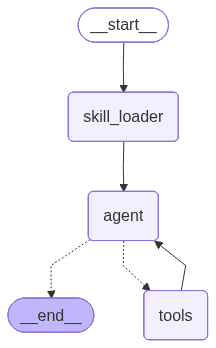

In [42]:
# view agent structure
text2sql_agent

---

## 🎬 Running and Testing the Text2SQL Agent

### Streaming Agent Execution

We create a utility function that:
- Executes the agent with a user query
- Streams intermediate reasoning steps (optional verbose mode)
- Displays the final business-friendly answer

**Verbose mode shows:**
- Agent's internal reasoning
- Which tools were called
- Tool inputs and outputs
- Multi-step ReAct loops

### Running and Streaming the Text-to-SQL Agent

This function executes the LangGraph Text-to-SQL agent, streams intermediate reasoning steps, and displays the final business-friendly answer.

In [43]:
# get agent streaming utils
!gdown 1dSyjcjlFoZpYEqv4P9Oi0-kU2gIoolMB

Downloading...
From (original): https://drive.google.com/uc?id=1dSyjcjlFoZpYEqv4P9Oi0-kU2gIoolMB
From (redirected): https://drive.google.com/uc?id=1dSyjcjlFoZpYEqv4P9Oi0-kU2gIoolMB&confirm=t&uuid=67e672ff-bb8d-43f3-aa38-547517448abf
To: /content/agent_utils.py
100% 6.45k/6.45k [00:00<00:00, 18.3MB/s]


In [44]:
from agent_utils import format_message
from langchain_core.messages import HumanMessage
from IPython.display import display, Markdown

def call_text2sql_agent(agent, query, verbose=False):

    # Stream the agent's execution with the given query
    for event in agent.stream(
        {"messages": [HumanMessage(content=query)]}, # input prompt
        stream_mode='values'  # Stream output as intermediate values
    ):
        # If verbose is enabled, print each intermediate message step-by-step
        if verbose:
            format_message(event["messages"][-1])

    # Display the final response from the agent as Markdown
    print('\n\nFinal Response:\n')
    if event["messages"][-1].text: # some llms have response stored under text attribute
        final_response = event["messages"][-1].text
        if '$' in final_response: # escaping any extra dollar signs if present
            final_response = final_response.replace('$', '\\$')
        display(Markdown(final_response))
    else:
        print(event["messages"][-1].content)

    # Return the overall event messages for optional downstream use
    return event["messages"]

---

## 🧪 Testing the Agent

### Test Query 1:

**Query:** "Give me total active accounts by account type"

**Reference Answer:**

> Here is the total count of active accounts by account type:
>
> Checking: 14 active accounts  
>
> Savings: 6 active accounts  
>
> Business Checking: 1 active account  
>
> These represent all currently active accounts in the database.


Your answer may not be exact but should be similar to this.


In [45]:
query = "Give me total active accounts by account type"

response = call_text2sql_agent(
    agent=text2sql_agent,
    query=query,
    verbose=True # for debugging, can turn it to False when needed
)


╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me total active accounts by account type                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me total active accounts by account type                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── ⚙️ Tool Request ─────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: sql_db_list_tables                                                                                │
│    Args: {}                                                                                                     │
│    ID: call_u47tHM0tWzSu8NuyE9s9KGeP                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Account, Branch, Customer, Dispute, Merchant, Transactions                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── ⚙️ Tool Request ─────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: sql_db_schema                                                                                     │
│    Args: {                                                                                                      │
│   "table_names": "Account"                                                                                      │
│ }                                                                                                               │
│    ID: call_S8fmqhepWJD0bUToezvT5o2Y                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭──────────────────────────────────────────────── ⚙️ Tool Request ─────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: sql_db_query                                                                                      │
│    Args: {                                                                                                      │
│   "query": "SELECT AccountType, COUNT(AccountID) AS ActiveAccountCount\nFROM Account\nWHERE Status =            │
│ 'Active'\nGROUP BY AccountType\nORDER BY ActiveAccountCount DESC"                                               │
│ }                                                                                                               │
│    ID: call_t0S1eObRvhddg1bg4kPegFry                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ [('Checking', 14), ('Savings', 6), ('Business Checking', 1)]                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────── 🤖 Assistant ──────────────────────────────────────────────────╮
│ There are currently 14 active Checking accounts, 6 active Savings accounts, and 1 active Business Checking      │
│ account in the bank.                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯



Final Response:



There are currently 14 active Checking accounts, 6 active Savings accounts, and 1 active Business Checking account in the bank.

View final response

In [46]:
display(Markdown(response[-1].text))

There are currently 14 active Checking accounts, 6 active Savings accounts, and 1 active Business Checking account in the bank.

### Test Query 2:

**Query:** "List the top 3 spending categories by total transaction value."

**Reference Answer:**

> The top 3 spending categories by total transaction value are:
>
> Travel with a total spend of 136,858.97 USD  
>
> Transfer with a total spend of 88,588.25 USD  
>
> Shopping with a total spend of 70,530.56 USD  
>
> These amounts represent the highest debit transaction totals across all categories.

Your answer may not be exact but should be similar to this.

In [47]:
query = "List the top 3 spending categories by total transaction value."

response = call_text2sql_agent(
    agent=text2sql_agent,
    query=query,
    verbose=False # for debugging, can turn it to True when needed
)




Final Response:



The top 3 spending categories by total transaction value are:
1. Travel with a total spend of \$136,858.97
2. Transfer with a total spend of \$88,588.25
3. Shopping with a total spend of \$70,530.56

These categories represent the highest debit transaction amounts in the banking insights database.

View final response

In [48]:
display(Markdown(response[-1].text))

The top 3 spending categories by total transaction value are:
1. Travel with a total spend of $136,858.97
2. Transfer with a total spend of $88,588.25
3. Shopping with a total spend of $70,530.56

These categories represent the highest debit transaction amounts in the banking insights database.

### Test Query 3:

**Query:** "Which branch has the highest number of customers."

**Reference Answer:**

> The branch with the highest number of customers is New York Wall Street, with a total of 8 customers.

Your answer may not be exact but should be similar to this.

In [49]:
query = "Which branch has the highest number of customers."

response = call_text2sql_agent(
    agent=text2sql_agent,
    query=query,
    verbose=False
)




Final Response:



The branch with the highest number of customers is "New York Wall Street," which serves 8 distinct customers.

View final response

In [50]:
display(Markdown(response[-1].text))

The branch with the highest number of customers is "New York Wall Street," which serves 8 distinct customers.

### Test Query 4:

**Query:** "Current balance for the top 5 accounts (all time). Show ids and names along with the amount."

**Reference Answer:**

> Here are the top 5 accounts by current balance (all time), showing account IDs, customer names, and balances in USD:
>
> Account ID 1016 - Rahul Mehta: 29,968.39 USD  
>
> Account ID 1021 - Christopher Lee: 16,174.20 USD  
>
> Account ID 1013 - Jessica Williams: 9,737.12 USD  
>
> Account ID 1008 - Yuki Tanaka: 9,662.86 USD  
>
> Account ID 1011 - Michael Chen: 9,615.17 USD

Your answer may not be exact but should be similar to this.

In [51]:
query = "Current balance for the top 5 accounts (all time). Show ids and names along with the amount."

response = call_text2sql_agent(
    agent=text2sql_agent,
    query=query,
    verbose=False
)



Final Response:



The current balances for the top 5 accounts (all time) are as follows:

1. Account ID 1016, Customer: Rahul Mehta, Balance: \$29,968.39
2. Account ID 1021, Customer: Christopher Lee, Balance: \$16,174.20
3. Account ID 1013, Customer: Jessica Williams, Balance: \$9,737.12
4. Account ID 1008, Customer: Yuki Tanaka, Balance: \$9,662.86
5. Account ID 1011, Customer: Michael Chen, Balance: \$9,615.17

These balances represent the net amount considering all credits and debits for each account.

View final response

In [52]:
display(Markdown(response[-1].text))

The current balances for the top 5 accounts (all time) are as follows:

1. Account ID 1016, Customer: Rahul Mehta, Balance: $29,968.39
2. Account ID 1021, Customer: Christopher Lee, Balance: $16,174.20
3. Account ID 1013, Customer: Jessica Williams, Balance: $9,737.12
4. Account ID 1008, Customer: Yuki Tanaka, Balance: $9,662.86
5. Account ID 1011, Customer: Michael Chen, Balance: $9,615.17

These balances represent the net amount considering all credits and debits for each account.

### Test Query 5:

**Query:** "Top 3 customers who spent the most on dining in 2025. Show ids and names along with the amount."

**Reference Answer:**

> The top 3 customers who spent the most on dining in 2025 are:
>
> Liam Murphy (CustomerID 15) with a total dining spend of 381.53 USD  
>
> Emily Rodriguez (CustomerID 3) with a total dining spend of 304.81 USD  
>
> Christopher Lee (CustomerID 10) with a total dining spend of 200.71 USD

Your answer may not be exact but should be similar to this.

In [53]:
query = "Top 3 customers who spent the most on dining in 2025. Show ids and names along with the amount."

response = call_text2sql_agent(
    agent=text2sql_agent,
    query=query,
    verbose=False
)




Final Response:



The top 3 customers who spent the most on dining in 2025 are:

1. Liam Murphy (Customer ID: 15) with a total dining spend of \$381.53
2. Emily Rodriguez (Customer ID: 3) with a total dining spend of \$304.81
3. Christopher Lee (Customer ID: 10) with a total dining spend of \$200.71

Let me know if you need any more details!

View final response

In [54]:
display(Markdown(response[-1].text))

The top 3 customers who spent the most on dining in 2025 are:

1. Liam Murphy (Customer ID: 15) with a total dining spend of $381.53
2. Emily Rodriguez (Customer ID: 3) with a total dining spend of $304.81
3. Christopher Lee (Customer ID: 10) with a total dining spend of $200.71

Let me know if you need any more details!

---

# 📊 Evaluating the Text2SQL Agent using LLM-as-a-Judge

## Why LLM-as-a-Judge?

Traditional evaluation methods (exact string matching, SQL equivalence checking) are too brittle for LLM-generated outputs.

**Challenges with traditional evaluation:**
- LLMs may phrase answers differently while being factually correct
- SQL queries can be logically equivalent but syntactically different
- Business answers may include extra context or formatting

**LLM-as-a-Judge approach:**

We use a **secondary LLM** (GPT-4.1-mini - ideally you should use a different and more powerful LLM in production settings) to:
1. Compare agent outputs to reference answers
2. Assess **semantic correctness** rather than exact matching
3. Provide nuanced verdicts (PASS/FAIL with explanations)

This mirrors how real-world systems are evaluated:
- Multiple correct phrasings may exist
- Focus on factual accuracy, not formatting
- Human-like judgment of answer quality

## Create Evaluation Test Cases

We define a small but representative set of **ground-truth evaluation queries** to measure the performance of the Text-to-SQL agent.

Each test case contains:

- A **natural language query**
- A **reference answer** obtained by directly querying the database

These test cases are stored in a **pandas DataFrame** to enable:

- Easy iteration over evaluation samples  
- Structured comparison between agent outputs and reference answers  
- Clear reporting of evaluation results  


In [55]:
import pandas as pd

# Placeholder for the DataFrame, which will be created after defining test cases
test_cases_df = None

In [56]:
# Define a set of ground-truth test cases for evaluation
# Each test case contains:
# - 'query': the user question or analytical prompt
# - 'reference_answer': the expected ideal answer used for comparison

test_cases = [
    {
        "query": "Which branch has the highest number of customers.",
        "reference_answer": """The branch with the highest number of customers is New York Wall Street, with a total of 8 customers.""",
    },
    {
        "query": "Top 3 customers who spent the most on dining in 2025. Show ids and names along with the amount.",
        "reference_answer": """The top 3 customers who spent the most on dining in 2025 are:

Liam Murphy (CustomerID 15) with a total dining spend of 381.53 USD

Emily Rodriguez (CustomerID 3) with a total dining spend of 304.81 USD

Christopher Lee (CustomerID 10) with a total dining spend of 200.71 USD
""",
    },
    {
        # Query testing ranking by dispute count (all-time aggregation)
        "query": "What are the top 3 merchants by number of disputes (all time)",
        "reference_answer": """The top 3 merchants by number of disputes (all time) are:

Walmart with 2 disputes

Amazon with 2 disputes

Starbucks with 2 disputes
""",
    }
]

# Convert the list of test cases into a pandas DataFrame
# This makes it easier to:
# - Iterate over test cases
# - Compare model outputs vs reference answers
# - Plug into automated evaluation pipelines
test_cases_df = pd.DataFrame(test_cases)

# Display the test cases for quick verification
display(test_cases_df)

,query,reference_answer
0,Which branch has the highest number of customers.,The branch with the highest number of customer...
1,Top 3 customers who spent the most on dining i...,The top 3 customers who spent the most on dini...
2,What are the top 3 merchants by number of disp...,The top 3 merchants by number of disputes (all...


---

## Implementing the LLM-as-a-Judge Evaluation Function

In this step, you will implement an evaluation function that uses a secondary LLM to **grade the agent's response** against a **ground-truth reference answer**.

### Function Overview

The `evaluate_response()` function takes three inputs:

- **query** — The original natural language question asked by the user
- **agent_response** — The answer generated by your Text2SQL agent
- **reference_answer** — The manually verified correct answer (ground truth)

### How It Works

1. **Constructs a detailed judge prompt** that includes:
   - The user's original query
   - The agent's response
   - The reference answer for comparison
   - Comprehensive evaluation criteria (PASS/FAIL conditions)

2. **Invokes the LLM judge** using the same `llm` model (GPT-4.1-mini) configured earlier - **In real-world scenarios use a different and more powerful LLM if possible**

3. **Returns the judge's verdict** as a string containing:
   - **Verdict**: Either "PASS" or "FAIL"
   - **Explanation**: Concise reasoning for the decision

### Evaluation Criteria

The judge uses **strict factual accuracy** combined with **flexible formatting**:

#### PASS Conditions:
✓ All factual information matches the reference answer  
✓ Completeness requirements met (e.g., all requested items shown)  
✓ Core entities and values are correct  
✓ Minor formatting differences are acceptable (number formats, whitespace, date formats)

#### FAIL Conditions:
✗ Missing required information (e.g., shows 3 items when 5 were requested)  
✗ Incorrect factual data (wrong names, numbers, relationships)  
✗ Wrong ranking order for "top N" queries  
✗ Hallucinated information not in reference answer  
✗ Answers a different question than asked

### Why This Approach?

Traditional exact string matching would reject valid responses that use different phrasing. LLM-as-a-Judge enables:

- **Semantic evaluation** — Focuses on meaning, not exact wording
- **Nuanced judgment** — Distinguishes between minor formatting issues and factual errors
- **Human-like assessment** — Evaluates like a domain expert would
- **Structured feedback** — Provides explanations for each verdict

This mirrors how real-world AI systems are evaluated, where multiple correct answers may exist.

---

**YOUR TURN: Implement this function below** ↓

In [ ]:
from langchain_core.messages import HumanMessage

def evaluate_response(query: str, agent_response: str, reference_answer: str) -> str:
    """
    Evaluates the agent's response against a reference answer using an LLM-as-a-judge approach.

    Args:
        query: The original natural language query.
        agent_response: The response generated by the text2sql agent.
        reference_answer: The manually derived correct answer.

    Returns:
        A string containing the judge's qualitative assessment and explanation.
    """

    # 
    judge_prompt = f"""You are an expert judge evaluating the correctness of a Text-to-SQL agent's response.

User Query: {query}

Agent Response:
{agent_response}

Reference Answer (Ground Truth):
{reference_answer}

Evaluate whether the Agent Response is factually correct compared to the Reference Answer.

PASS if:
- All key facts, numbers, names, and values match the reference answer
- Minor formatting differences are acceptable (e.g., different number formats, whitespace)
- The response is complete (all requested items are present)

FAIL if:
- Any factual data is incorrect (wrong numbers, names, or values)
- Required items are missing (e.g., shows 3 when 5 were requested)
- Ranking order is wrong for "top N" queries
- The response contains hallucinated data not in the reference answer
- The response answers a different question

Respond with:
Verdict: PASS or FAIL
Explanation: A brief explanation of your decision.
"""
    response = agent_llm.invoke([HumanMessage(content=judge_prompt)])
    return response.content

print("✓ evaluate_response function defined")


✓ evaluate_response function defined


---

## Execute Queries and Evaluate Agent Responses

In this step, you will implement a comprehensive **evaluation suite function** that systematically tests your Text2SQL agent across multiple queries.

### Function Overview

The `run_evaluation_suite()` function automates the entire evaluation workflow:

**Inputs:**
- **test_cases_df** — DataFrame containing test queries and reference answers
- **text2sql_agent** — Your compiled LangGraph agent
- **verbose** — Optional flag to show detailed agent execution steps

**Returns:**
- **results_df** — DataFrame with complete evaluation results including agent responses and judge verdicts

### What This Function Does

For each test case in your evaluation dataset, the function:

1. **Extracts the query and reference answer** from the test case DataFrame
2. **Executes the query** using your `call_text2sql_agent` function
3. **Captures the agent's final response** from the execution
4. **Evaluates the response** against the reference answer using `evaluate_response`
5. **Displays formatted output** showing:
   - The original query
   - Agent's response
   - Reference answer
   - Judge's verdict with explanation
6. **Stores all results** in a structured list for analysis
7. **Returns a DataFrame** with complete evaluation metrics

### Why This Approach?

This function enables:
- **Automated testing** — Run multiple test cases without manual intervention
- **Consistent evaluation** — Same process applied to all queries
- **Structured results** — Easy to analyze, compare, and report
- **Progress tracking** — Clear visibility into which test cases pass or fail

This systematic approach helps you understand your agent's **accuracy, completeness, and overall reliability** across diverse query types.

---

**YOUR TURN: Implement this function below** ↓

In [ ]:
import pandas as pd

def run_evaluation_suite(test_cases_df: pd.DataFrame, text2sql_agent, verbose: bool = False) -> pd.DataFrame:
    """
    Run evaluation suite on test cases and return results DataFrame.

    Args:
        test_cases_df: DataFrame with 'query' and 'reference_answer' columns
        text2sql_agent: Compiled LangGraph agent
        verbose: Whether to show detailed agent execution

    Returns:
        DataFrame with evaluation results including PASS/FAIL verdicts
    """

    # 
    results = []

    for idx, row in test_cases_df.iterrows():
        query = row["query"]
        reference_answer = row["reference_answer"]

        print(f"\n{'='*60}")
        print(f"Test Case {idx + 1}: {query}")
        print("="*60)

        # Execute agent
        agent_response_messages = call_text2sql_agent(
            agent=text2sql_agent,
            query=query,
            verbose=verbose
        )

        # Extract final text response
        if agent_response_messages and hasattr(agent_response_messages[-1], "text") and agent_response_messages[-1].text:
            agent_response = agent_response_messages[-1].text
        elif agent_response_messages and hasattr(agent_response_messages[-1], "content"):
            agent_response = agent_response_messages[-1].content
        else:
            agent_response = "No response generated."

        print(f"\nAgent Response:\n{agent_response}")
        print(f"\nReference Answer:\n{reference_answer}")

        # Evaluate
        verdict = evaluate_response(query, agent_response, reference_answer)
        print(f"\nJudge Verdict:\n{verdict}")

        results.append({
            "query": query,
            "agent_response": agent_response,
            "reference_answer": reference_answer,
            "judge_verdict": verdict
        })

    results_df = pd.DataFrame(results)
    print(f"\n\n✓ Evaluation complete: {len(results_df)} test cases evaluated")
    return results_df

print("✓ run_evaluation_suite function defined")


✓ run_evaluation_suite function defined


In [59]:
    # Run evaluation
    results = run_evaluation_suite(
        test_cases_df=test_cases_df,
        text2sql_agent=text2sql_agent,
        verbose=False
    )


Test Case 1: Which branch has the highest number of customers.


Final Response:



The branch with the highest number of customers is "New York Wall Street," serving 8 distinct customers.


Agent Response:
The branch with the highest number of customers is "New York Wall Street," serving 8 distinct customers.

Reference Answer:
The branch with the highest number of customers is New York Wall Street, with a total of 8 customers.

Judge Verdict:
Verdict: PASS  
Explanation: The agent response correctly identifies the branch "New York Wall Street" as having the highest number of customers, with the number 8 matching the reference answer. Minor formatting differences, such as the use of quotes and phrasing, do not affect factual correctness. The response is complete and directly answers the query.

Test Case 2: Top 3 customers who spent the most on dining in 2025. Show ids and names along with the amount.


Final Response:



The top 3 customers who spent the most on dining in 2025 are:

1. Liam Murphy (CustomerID 15) with a total dining spend of \$381.53
2. Emily Rodriguez (CustomerID 3) with a total dining spend of \$304.81
3. Christopher Lee (CustomerID 10) with a total dining spend of \$200.71

These amounts represent their total debit transactions categorized as dining in the year 2025.


Agent Response:
The top 3 customers who spent the most on dining in 2025 are:

1. Liam Murphy (CustomerID 15) with a total dining spend of $381.53
2. Emily Rodriguez (CustomerID 3) with a total dining spend of $304.81
3. Christopher Lee (CustomerID 10) with a total dining spend of $200.71

These amounts represent their total debit transactions categorized as dining in the year 2025.

Reference Answer:
The top 3 customers who spent the most on dining in 2025 are:

Liam Murphy (CustomerID 15) with a total dining spend of 381.53 USD

Emily Rodriguez (CustomerID 3) with a total dining spend of 304.81 USD

Christopher Lee (CustomerID 10) with a total dining spend of 200.71 USD


Judge Verdict:
Verdict: PASS  
Explanation: The agent response matches the reference answer in all key facts: customer names, IDs, amounts, and ranking order. The minor formatting differences (e.g., "$" sign and "USD") are acceptable. The response is complete and correctly answers the query.

Test Case 3: What are 

The top 3 merchants by number of disputes (all time) are Walmart, Amazon, and Starbucks. Each of these merchants has 2 disputes recorded against them.


Agent Response:
The top 3 merchants by number of disputes (all time) are Walmart, Amazon, and Starbucks. Each of these merchants has 2 disputes recorded against them.

Reference Answer:
The top 3 merchants by number of disputes (all time) are:

Walmart with 2 disputes

Amazon with 2 disputes

Starbucks with 2 disputes


Judge Verdict:
Verdict: PASS  
Explanation: The agent response correctly lists the top 3 merchants (Walmart, Amazon, Starbucks) with the exact number of disputes (2 each) as in the reference answer. The formatting differences are minor and acceptable, and the response is complete and factually accurate.


✓ Evaluation complete: 3 test cases evaluated


In [60]:
# view eval dataframe
results

,query,agent_response,reference_answer,judge_verdict
0,Which branch has the highest number of customers.,The branch with the highest number of customer...,The branch with the highest number of customer...,Verdict: PASS \nExplanation: The agent respon...
1,Top 3 customers who spent the most on dining i...,The top 3 customers who spent the most on dini...,The top 3 customers who spent the most on dini...,Verdict: PASS \nExplanation: The agent respon...
2,What are the top 3 merchants by number of disp...,The top 3 merchants by number of disputes (all...,The top 3 merchants by number of disputes (all...,Verdict: PASS \nExplanation: The agent respon...
